# Построить прогноз на 8 месяцев методом сезонной декомпозиции

Общее описание данных

Гостиницы Чикаго.
В таблицах представлена статистика коэффициента загрузки гостиниц и средней цены по двум районам Чикаго: Chicago Central Business District Hotel Statistics и Chicago Metropolitan Area Hotel Statistics
Данные собирались ежемесячно с января 1994 по апрель 2003

Источник данных: http://www.choosechicago.com/.

Вариант 3 выполняют те, чья фамилия начинается с букв Л - С

Вариант 3:
Коэффициент загрузки гостиниц в процентах (Hotel Occupancy (in %))
Данные для Chicago Central Business District Hotel Statistics. Предоставлены средние значения процента занятых номеров за один день. Усреднение по отелям и по дням месяца.
Данные расположены в столбце x3 файла Chicago_hotels.csv

In [4]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

# Процедура сезонной декомпозиции
from statsmodels.tsa.seasonal import seasonal_decompose

# Процедура обыкновенной линейной регрессии
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score, mean_squared_error

# Чтобы графики отображались в ноутбуке
%matplotlib inline

In [26]:
df = df = pd.read_csv('/content/data.csv', sep=';', decimal=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date1   112 non-null    object 
 1   date2   112 non-null    int64  
 2   x1      112 non-null    float64
 3   x2      112 non-null    float64
 4   x3      112 non-null    float64
 5   x4      112 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 5.4+ KB


Оставляем только дату в формате "Месяц Год" и столбец x3

In [63]:
df3 = df[['date1', 'date2', 'x3']].copy()
df3['date'] = df3['date1'].str.strip() + ' ' + df3['date2'].astype(str)
df3 = df3[['date', 'x3']]

# Проверка
df3.head()

,date,x3
0,January 1994,51.9
1,February 1994,60.1
2,March 1994,65.0
3,April 1994,69.8
4,May 1994,72.4


Для декомпозиции используем только ряд x3

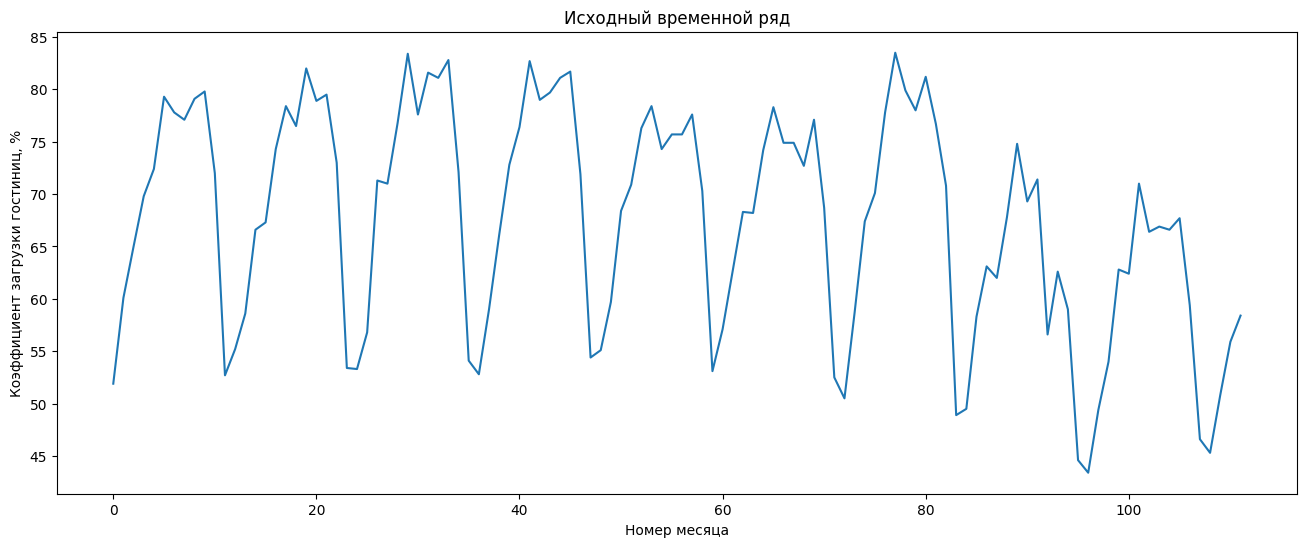

In [71]:
ts = df3['x3'].copy()

plt.figure(figsize=(16, 6))
plt.plot(ts)
plt.title('Исходный временной ряд')
plt.xlabel('Номер месяца')
plt.ylabel('Коэффициент загрузки гостиниц, %')
plt.show()

В ряде наблюдается единичный выброс. Чтобы он не искажал оценку тренда и прогноз, выполним мягкое сглаживание по квантилям. Мы не удаляем наблюдение, а только ограничиваем экстремальные значения.

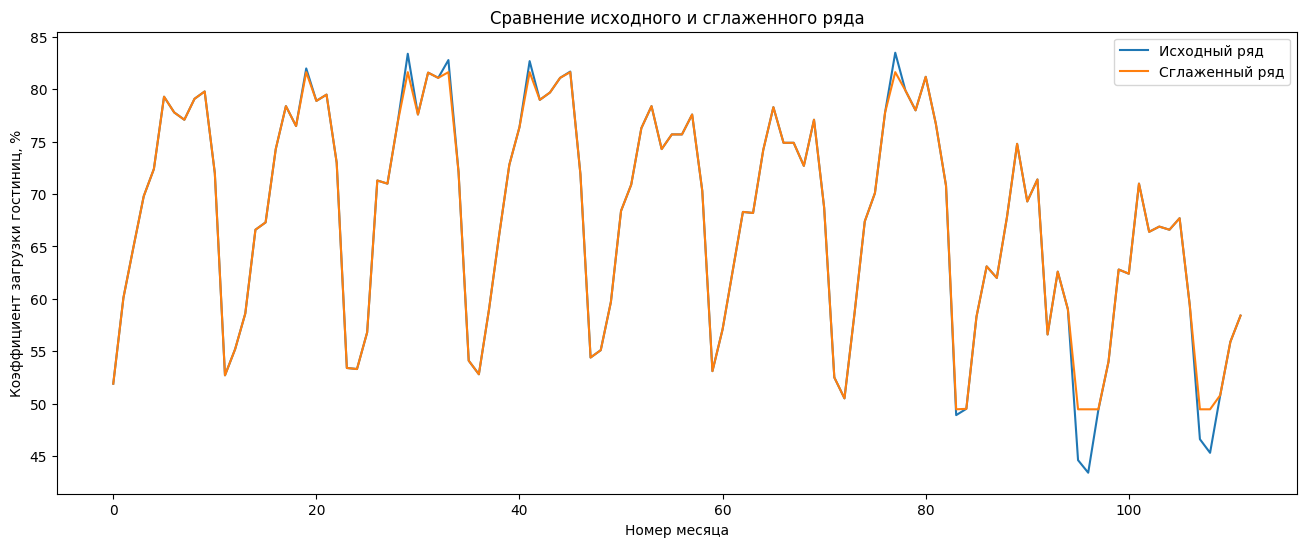

In [72]:
ts_clean = ts.clip(
    lower=ts.quantile(0.05),
    upper=ts.quantile(0.95)
)

plt.figure(figsize=(16, 6))
plt.plot(ts, label='Исходный ряд')
plt.plot(ts_clean, label='Сглаженный ряд')
plt.title('Сравнение исходного и сглаженного ряда')
plt.xlabel('Номер месяца')
plt.ylabel('Коэффициент загрузки гостиниц, %')
plt.legend(loc='best')
plt.show()


Используем аддитивную модель, так как амплитуда сезонных колебаний остаётся примерно постоянной на протяжении всего периода. Период сезонности = 12, так как данные ежемесячные.


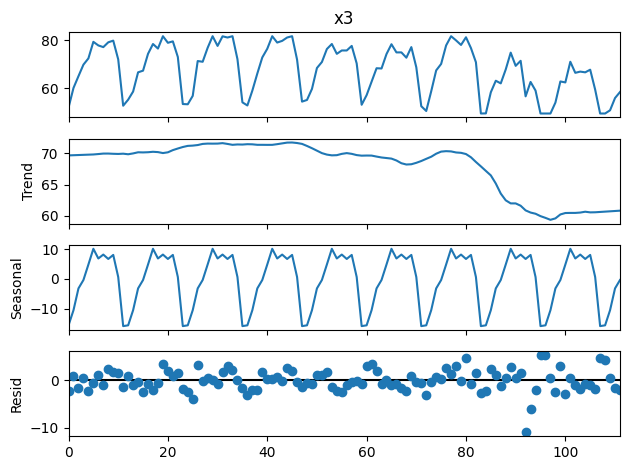

In [69]:
result = seasonal_decompose(
    ts_clean,
    model='additive',
    period=12,
    extrapolate_trend='freq'
)

# График декомпозиции
result.plot()
plt.tight_layout()
plt.show()

В результате сезонной декомпозиции временной ряд был разложен на тренд, сезонную компоненту и случайную составляющую. Обнаружена выраженная сезонность с постоянной амплитудой, а также умеренный нисходящий тренд в конце периода. Остаточная компонента не содержит выраженной структуры и колеблется около нуля, что свидетельствует о корректности выбранной аддитивной модели.

Для аддитивной модели сезонную компоненту вычитаем

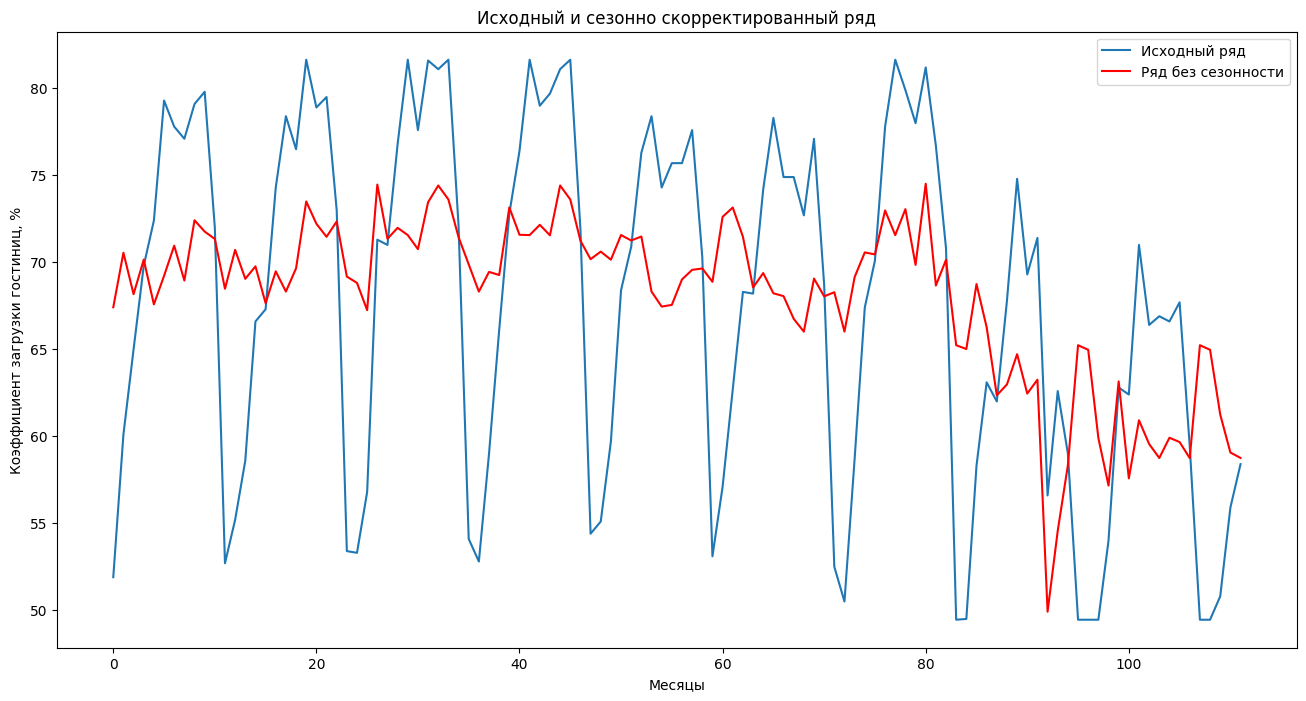

In [73]:
sa = ts_clean - result.seasonal

plt.figure(figsize=(16, 8))
plt.plot(ts_clean.values, label='Исходный ряд')
plt.plot(sa.values, label='Ряд без сезонности', color='red')
plt.legend(loc='best')
plt.xlabel('Месяцы')
plt.ylabel('Коэффициент загрузки гостиниц, %')
plt.title('Исходный и сезонно скорректированный ряд')
plt.show()

Формируем номер месяца и полиномиальные признаки

In [74]:
trend_df = pd.DataFrame({
    'trend': result.trend,
    'month_num': np.arange(1, len(ts_clean) + 1)
})

trend_df['num2'] = trend_df['month_num'] ** 2
trend_df['num3'] = trend_df['month_num'] ** 3

# Целевая переменная — трендовая компонента
y = trend_df['trend']

# Наборы признаков для разных моделей тренда
X1 = trend_df[['month_num']]                    # линейный тренд
X2 = trend_df[['month_num', 'num2']]            # квадратичный тренд
X3 = trend_df[['month_num', 'num2', 'num3']]    # кубический тренд


In [75]:
# Линейная модель
model1 = LinearRegression()
model1.fit(X1, y)
y1 = model1.predict(X1)

coef1 = pd.DataFrame(
    list(zip(['intercept'] + X1.columns.tolist(), (model1.intercept_,) + tuple(model1.coef_))),
    columns=['predictor', 'coef']
)
print('Коэффициенты линейной модели:')
display(coef1)

# Квадратичная модель
model2 = LinearRegression()
model2.fit(X2, y)
y2 = model2.predict(X2)

coef2 = pd.DataFrame(
    list(zip(['intercept'] + X2.columns.tolist(), (model2.intercept_,) + tuple(model2.coef_))),
    columns=['predictor', 'coef']
)
print('Коэффициенты квадратичной модели:')
display(coef2)

# Кубическая модель
model3 = LinearRegression()
model3.fit(X3, y)
y3 = model3.predict(X3)

coef3 = pd.DataFrame(
    list(zip(['intercept'] + X3.columns.tolist(), (model3.intercept_,) + tuple(model3.coef_))),
    columns=['predictor', 'coef']
)
print('Коэффициенты кубической модели:')
display(coef3)

Коэффициенты линейной модели:


,predictor,coef
0,intercept,73.538455
1,month_num,-0.097581


Коэффициенты квадратичной модели:


,predictor,coef
0,intercept,68.639487
1,month_num,0.160259
2,num2,-0.002282


Коэффициенты кубической модели:


,predictor,coef
0,intercept,6.866556e+01
1,month_num,1.575504e-01
2,num2,-2.222112e-03
3,num3,-3.519868e-07


Сравниваем по R2 и RMSE

In [76]:
compare = pd.DataFrame({
    'model': ['Линейная', 'Квадратичная', 'Кубическая'],
    'R2': [
        r2_score(y, y1),
        r2_score(y, y2),
        r2_score(y, y3)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y, y1)),
        np.sqrt(mean_squared_error(y, y2)),
        np.sqrt(mean_squared_error(y, y3))
    ]
})

print('Сравнение моделей тренда:')
display(compare)


Сравнение моделей тренда:


,model,R2,RMSE
0,Линейная,0.606948,2.538785
1,Квадратичная,0.884389,1.376897
2,Кубическая,0.884394,1.376866


Визуально сравниваем, какая модель лучше описывает тренд

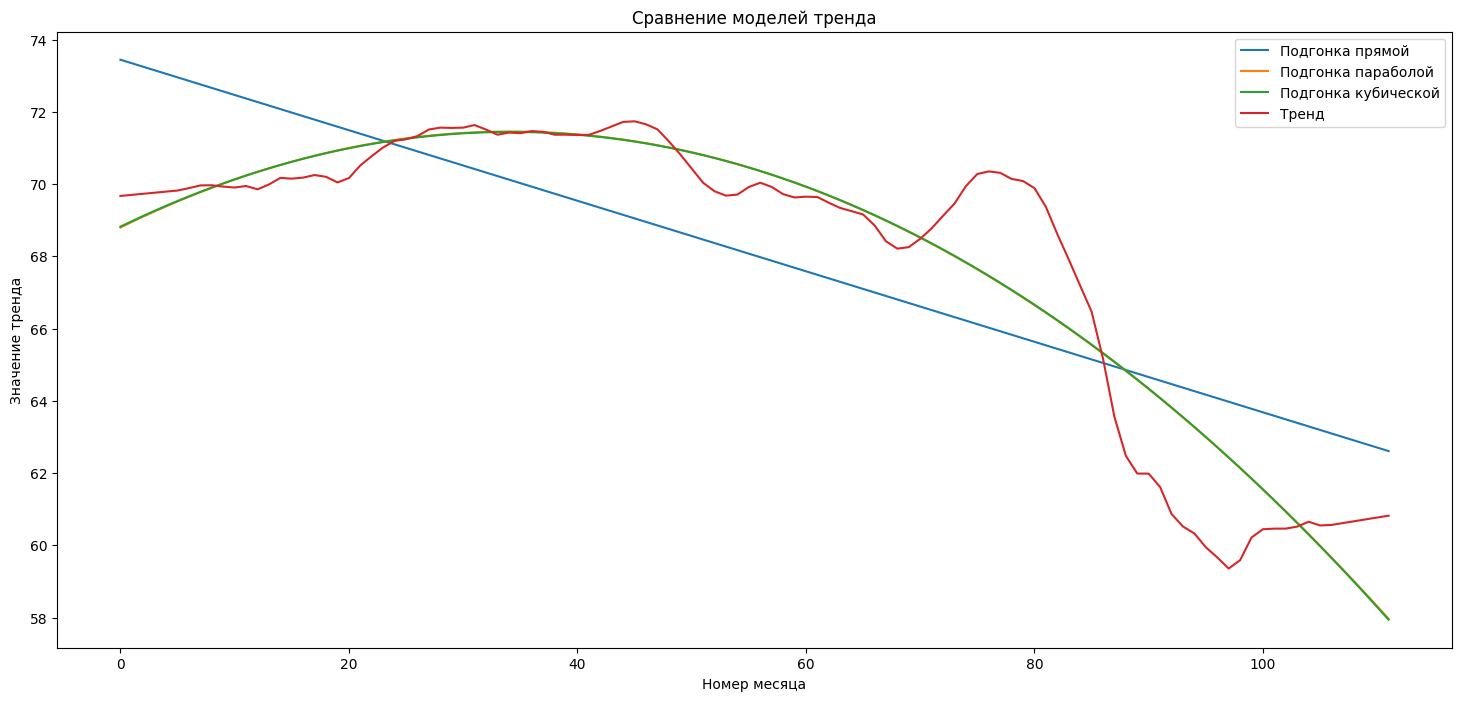

In [81]:
pred_trend = pd.DataFrame({
    'Подгонка прямой': y1,
    'Подгонка параболой': y2,
    'Подгонка кубической': y3,
    'Тренд': y
})

pred_trend.plot(figsize=(18, 8))
plt.title('Сравнение моделей тренда')
plt.xlabel('Номер месяца')
plt.ylabel('Значение тренда')
plt.show()


Для прогноза выбираем квадратичную модель. Она хорошо описывает тренд, но при этом проще и устойчивее, чем кубическая модель.


In [82]:
selected_model = model2

В исходном ряду 112 наблюдений. Прогноз строим на следующие 8 месяцев: 113–120

In [83]:
horizon = 8

X_forecast = pd.DataFrame({
    'month_num': np.arange(len(ts_clean) + 1, len(ts_clean) + horizon + 1)
})

X_forecast['num2'] = X_forecast['month_num'] ** 2

X_forecast

,month_num,num2
0,113,12769
1,114,12996
2,115,13225
3,116,13456
4,117,13689
5,118,13924
6,119,14161
7,120,14400


In [84]:
trend_forecast = selected_model.predict(X_forecast)

print('Прогноз тренда на 8 месяцев:')
print(trend_forecast)

Прогноз тренда на 8 месяцев:
[57.61279513 57.25509158 56.89282449 56.52599385 56.15459966 55.77864193
 55.39812064 55.01303581]


Последнее фактическое наблюдение — апрель 2003. Значит прогноз строится на: май, июнь, июль, август, сентябрь, октябрь, ноябрь, декабрь. Поэтому берём сезонные поправки именно для месяцев 5–12.

In [85]:
seasonal_pattern = result.seasonal.iloc[:12].to_numpy()
seasonal_future = seasonal_pattern[4:12]

# Для аддитивной модели сезонные поправки ПРИБАВЛЯЕМ
forecast = trend_forecast + seasonal_future

print('Итоговый прогноз на 8 месяцев:')
print(forecast)

Итоговый прогноз на 8 месяцев:
[62.43102164 67.3361191  63.73748872 64.67447752 62.83882408 63.81221819
 56.05424774 39.23319206]


,Период,Прогноз x3
0,May 2003,62.431022
1,June 2003,67.336119
2,July 2003,63.737489
3,August 2003,64.674478
4,September 2003,62.838824
5,October 2003,63.812218
6,November 2003,56.054248
7,December 2003,39.233192


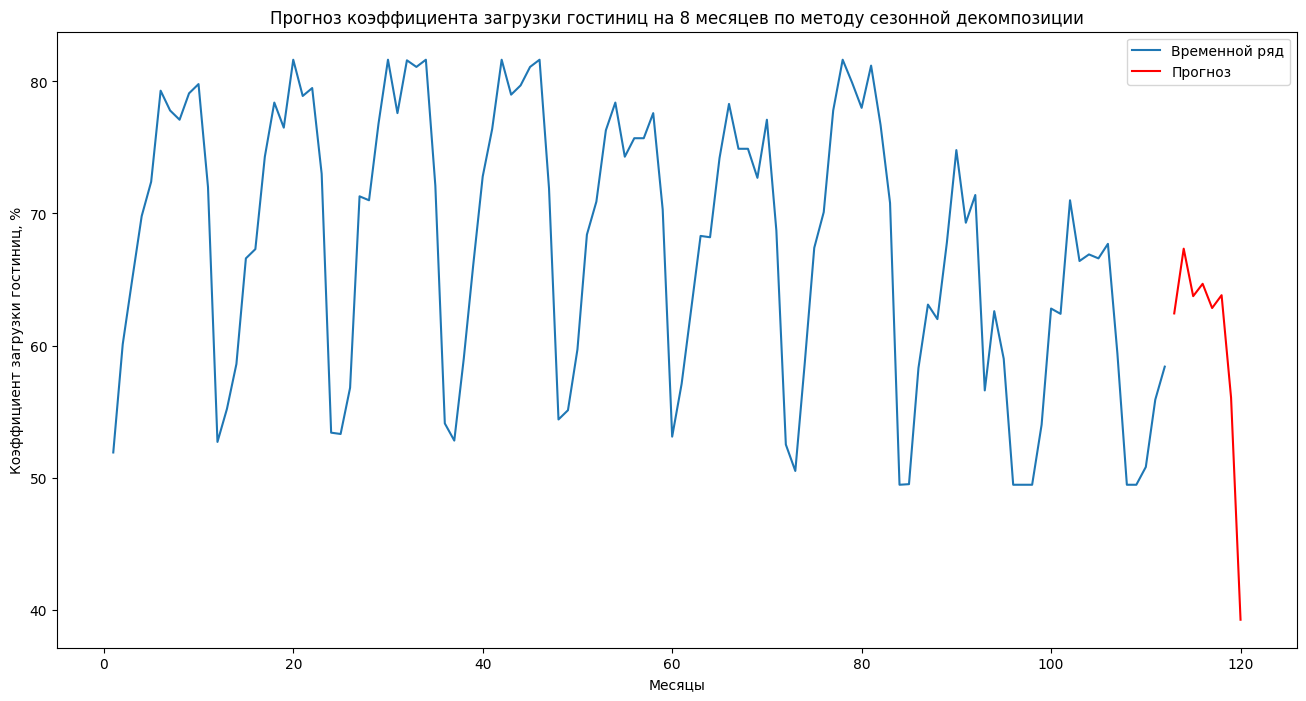

In [88]:
forecast_labels = [
    'May 2003',
    'June 2003',
    'July 2003',
    'August 2003',
    'September 2003',
    'October 2003',
    'November 2003',
    'December 2003'
]

forecast_result = pd.DataFrame({
    'Период': forecast_labels,
    'Прогноз x3': forecast
})

display(forecast_result)

plt.figure(figsize=(16, 8))

plt.plot(np.arange(1, len(ts_clean) + 1), ts_clean.values, label='Временной ряд')
plt.plot(
    np.arange(len(ts_clean) + 1, len(ts_clean) + horizon + 1),
    forecast,
    label='Прогноз',
    color='red'
)

plt.legend(loc='best')
plt.xlabel('Месяцы')
plt.ylabel('Коэффициент загрузки гостиниц, %')
plt.title('Прогноз коэффициента загрузки гостиниц на 8 месяцев по методу сезонной декомпозиции')
plt.show()